<a href="https://colab.research.google.com/github/alexadandridge/AdvancedMachineLearning/blob/master/Alexa_DandridgeCopy_of_Inclass_05_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 RNN

### Importing libraries

In [1]:
# Libraries

import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Load & inspect data

In [2]:
# Uploading dataset into Colab
from google.colab import files
uploaded = files.upload()

Saving dc.csv to dc.csv


In [3]:
# Loading the dataset
import pandas as pd
bitcoin = pd.read_csv("dc.csv")
bitcoin.head()

,Unnamed: 0,open_USD,high_USD,low_USD,close_USD,volume
0,2021-01-30,34246.28,34933.00,32825.00,34218.54,43072
1,2021-01-29,33368.18,38531.90,31915.40,34252.20,231827
2,2021-01-28,30362.19,33783.98,29842.10,33364.86,92621
3,2021-01-27,32464.01,32557.29,29241.72,30366.15,95911
4,2021-01-26,32254.19,32921.88,30837.37,32467.77,84972


In [4]:

bitcoin = bitcoin.rename(
    columns={"Unnamed: 0": "date"}
)

bitcoin["date"] = pd.to_datetime(bitcoin["date"])

bitcoin = (
    bitcoin
    .sort_values("date")
    .reset_index(drop=True)
)

print(bitcoin.shape)

bitcoin.head()

(1000, 6)


,date,open_USD,high_USD,low_USD,close_USD,volume
0,2018-05-07,9661.02,9689.67,9181.00,9365.00,33787
1,2018-05-08,9365.00,9475.70,9060.54,9187.56,25533
2,2018-05-09,9178.00,9390.00,8965.00,9310.00,25673
3,2018-05-10,9310.00,9395.12,8970.00,9002.20,25055
4,2018-05-11,9002.21,9016.80,8341.00,8400.00,48227


In [5]:
# Basic inspection

bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1000 non-null   datetime64[ns]
 1   open_USD   1000 non-null   float64       
 2   high_USD   1000 non-null   float64       
 3   low_USD    1000 non-null   float64       
 4   close_USD  1000 non-null   float64       
 5   volume     1000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 47.0 KB


In [6]:
# Summary statistics

bitcoin.describe()

,date,open_USD,high_USD,low_USD,close_USD,volume
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2019-09-18 12:00:00,9285.762120,9542.880270,9011.393200,9310.335850,53100.498000
min,2018-05-07 00:00:00,3211.710000,3276.500000,3156.260000,3211.720000,5743.000000
25%,2019-01-11 18:00:00,6467.192500,6582.255000,6325.015000,6466.762500,30045.750000
50%,2019-09-18 12:00:00,8189.695000,8351.630000,8002.045000,8189.330000,43795.500000
75%,2020-05-25 06:00:00,10216.860000,10419.562500,9907.977500,10220.170000,64909.250000
max,2021-01-30 00:00:00,40586.960000,41950.000000,38720.000000,40582.810000,402201.000000
std,NaN,5793.522832,6075.604427,5483.524463,5846.917681,35329.832031


Visualizing the target variable

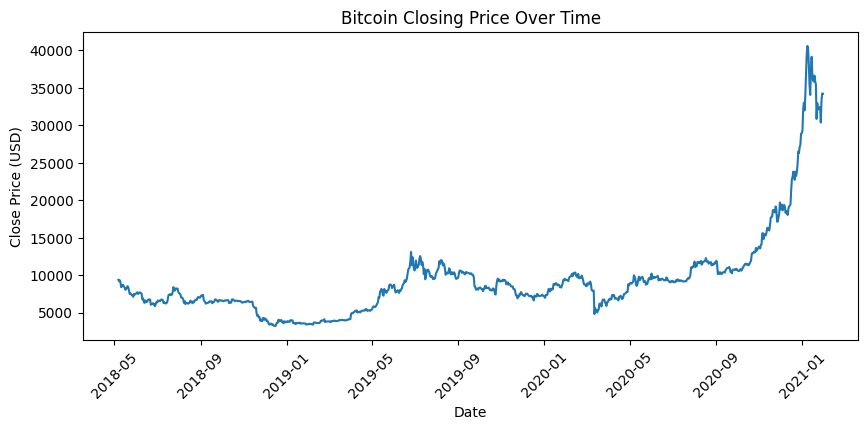

In [7]:
# Visualize closing price over time

plt.figure(figsize=(10, 4))

plt.plot(
    bitcoin["date"],
    bitcoin["close_USD"]
)

plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.xticks(rotation=45)

plt.show()

### Preparing data for recurrent modeling

In [8]:
# Prepare Bitcoin data for recurrent models

features = [
    "open_USD",
    "high_USD",
    "low_USD",
    "close_USD",
    "volume"
]

target_col = "close_USD"

bitcoin_model = bitcoin[["date"] + features].copy()

print("Unique dates:", bitcoin_model["date"].nunique())
print("Rows:", len(bitcoin_model))

scaler_bitcoin = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler_bitcoin.fit_transform(
    bitcoin_model[features]
)

look_back = 10                                                  # use 10 previous days to predict next close

target_index = features.index(target_col)

Unique dates: 1000
Rows: 1000


### Useful functions

In [9]:
# Function to create recurrent sequence windows

def create_sequences(dataset, target_index, look_back=10):

    X, y = [], []

    for i in range(len(dataset) - look_back):

        X.append(
            dataset[i:i + look_back, :]
        )                                                       # previous look_back days

        y.append(
            dataset[i + look_back, target_index]
        )                                                       # next day's close_USD

    return np.array(X), np.array(y)

In [10]:
# Function to visualize training curves

def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(
        history.history["loss"],
        label="Training Loss"
    )

    axes[0].plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")

    axes[0].legend()

    # MAE
    axes[1].plot(
        history.history["mean_absolute_error"],
        label="Training MAE"
    )

    axes[1].plot(
        history.history["val_mean_absolute_error"],
        label="Validation MAE"
    )

    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")

    axes[1].legend()

    plt.tight_layout()

    plt.show()

In [11]:
# Function to evaluate forecasting performance

def evaluate_and_plot(
    model,
    trainX,
    testX,
    trainY,
    testY,
    scaler,
    target_index,
    title
):

    # Predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Create arrays for inverse scaling
    train_dummy = np.zeros((len(train_pred), len(features)))
    test_dummy = np.zeros((len(test_pred), len(features)))

    train_dummy[:, target_index] = train_pred.flatten()
    test_dummy[:, target_index] = test_pred.flatten()

    trainY_dummy = np.zeros((len(trainY), len(features)))
    testY_dummy = np.zeros((len(testY), len(features)))

    trainY_dummy[:, target_index] = trainY
    testY_dummy[:, target_index] = testY

    # Inverse transform
    train_pred_inv = scaler.inverse_transform(train_dummy)[:, target_index]
    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]

    trainY_inv = scaler.inverse_transform(trainY_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    train_mae = mean_absolute_error(trainY_inv, train_pred_inv)
    test_mae = mean_absolute_error(testY_inv, test_pred_inv)

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    print(f"{title} Train MAE: {train_mae:.2f}")
    print(f"{title} Test MAE: {test_mae:.2f}")

    # Plot predictions
    plt.figure(figsize=(10, 4))

    plt.plot(
        testY_inv,
        label="Actual"
    )

    plt.plot(
        test_pred_inv,
        label="Predicted"
    )

    plt.title(title + " Test Predictions")

    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(
        style="plain",
        axis="y"
    )

    plt.legend()

    plt.show()

In [12]:
# Function to compare model metrics

def evaluate_metrics(
    model,
    testX,
    testY,
    scaler,
    target_index
):

    test_pred = model.predict(testX)

    test_dummy = np.zeros((len(test_pred), len(features)))
    test_dummy[:, target_index] = test_pred.flatten()

    testY_dummy = np.zeros((len(testY), len(features)))
    testY_dummy[:, target_index] = testY

    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Creating train/test recurrent tensors

In [13]:
# Create train/test recurrent tensors

train_size = int(len(scaled_features) * 0.8)                    # chronological 80/20 split

train_bitcoin = scaled_features[:train_size]                    # earlier data
test_bitcoin = scaled_features[train_size:]                     # held-out future data

trainX_bitcoin, trainY_bitcoin = create_sequences(
    train_bitcoin,
    target_index,
    look_back
)

testX_bitcoin, testY_bitcoin = create_sequences(
    test_bitcoin,
    target_index,
    look_back
)

print("trainX_bitcoin shape:", trainX_bitcoin.shape)
print("testX_bitcoin shape:", testX_bitcoin.shape)
print("trainY_bitcoin shape:", trainY_bitcoin.shape)
print("testY_bitcoin shape:", testY_bitcoin.shape)

trainX_bitcoin shape: (790, 10, 5)
testX_bitcoin shape: (190, 10, 5)
trainY_bitcoin shape: (790,)
testY_bitcoin shape: (190,)


### Baseline SimpleRNN model

In [14]:
# Build and train baseline SimpleRNN model

simple_rnn_model = Sequential([
    SimpleRNN(
        8,                                     # small baseline recurrent layer
        activation="tanh",                     # standard activation for SimpleRNN
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

simple_rnn_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

simple_rnn_history = simple_rnn_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0108 - mean_absolute_error: 0.0820 - val_loss: 0.0113 - val_mean_absolute_error: 0.0747
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041 - mean_absolute_error: 0.0477 - val_loss: 0.0080 - val_mean_absolute_error: 0.0571
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - mean_absolute_error: 0.0402 - val_loss: 0.0062 - val_mean_absolute_error: 0.0496
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022 - mean_absolute_error: 0.0343 - val_loss: 0.0049 - val_mean_absolute_error: 0.0438
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0018 - mean_absolute_error: 0.0304 - val_loss: 0.0039 - val_mean_absolute_error: 0.0391
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015 - mean_absolute_error: 0.0279 - val_loss: 0.0032 - val_mean_absolute_error: 0.0353
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - mean_absolute_error: 0.0259 - val_loss: 0.0026 - val

Visualizing training

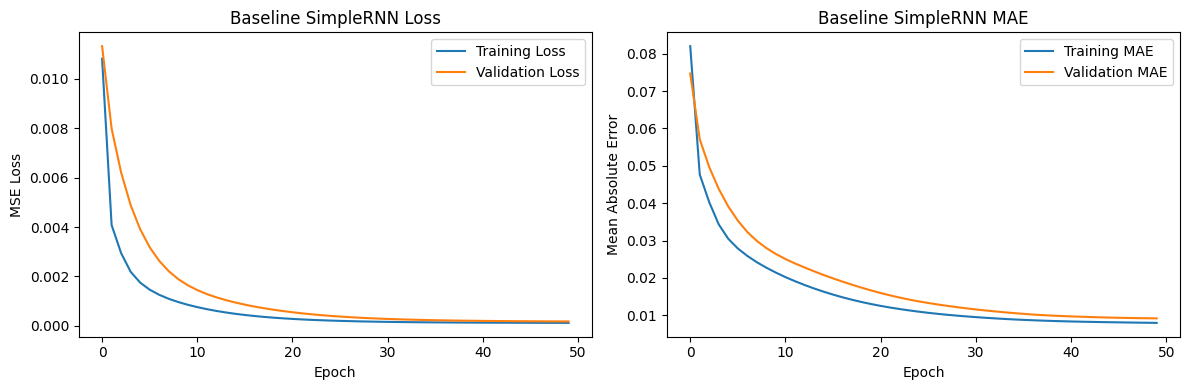

In [15]:
# Visualize SimpleRNN training performance

plot_training_curves(
    simple_rnn_history,
    "Baseline SimpleRNN"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Baseline SimpleRNN Train RMSE: 493.52
Baseline SimpleRNN Test RMSE: 3953.11
Baseline SimpleRNN Train MAE: 364.83
Baseline SimpleRNN Test MAE: 2409.82


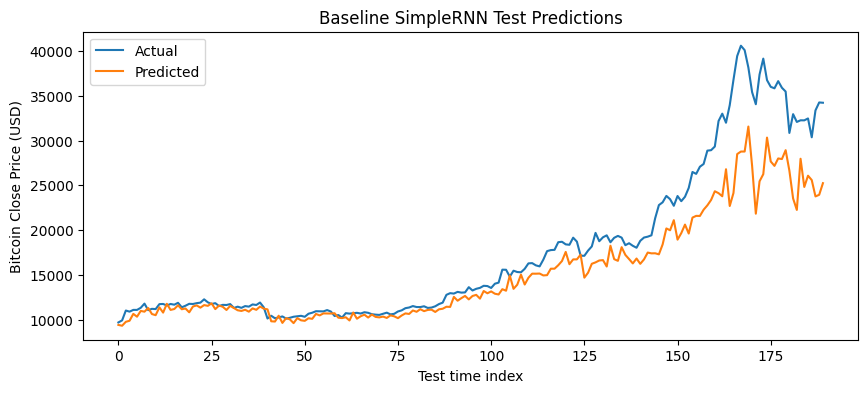

In [16]:
# Evaluate SimpleRNN on held-out future test data

evaluate_and_plot(
    simple_rnn_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline SimpleRNN"
)

### Baseline LSTM Model

In [17]:
# Build and train baseline LSTM model

lstm_model = Sequential([
    LSTM(
        8,                                     # small baseline LSTM layer
        activation="tanh",                     # standard LSTM hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

lstm_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

lstm_history = lstm_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0018 - mean_absolute_error: 0.0332 - val_loss: 0.0052 - val_mean_absolute_error: 0.0536
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - mean_absolute_error: 0.0257 - val_loss: 0.0043 - val_mean_absolute_error: 0.0484
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.7141e-04 - mean_absolute_error: 0.0183 - val_loss: 0.0033 - val_mean_absolute_error: 0.0409
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.8698e-04 - mean_absolute_error: 0.0150 - val_loss: 0.0024 - val_mean_absolute_error: 0.0340
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.2297e-04 - mean_absolute_error: 0.0139 - val_loss: 0.0019 - val_mean_absolute_error: 0.0293
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.8944e-04 - mean_absolute_error: 0.0132 - val_loss: 0.0015 - val_mean_absolute_error: 0.0259
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.6544e-04 - mean_absolute_error: 0.0126 - val_l

Visualizing training

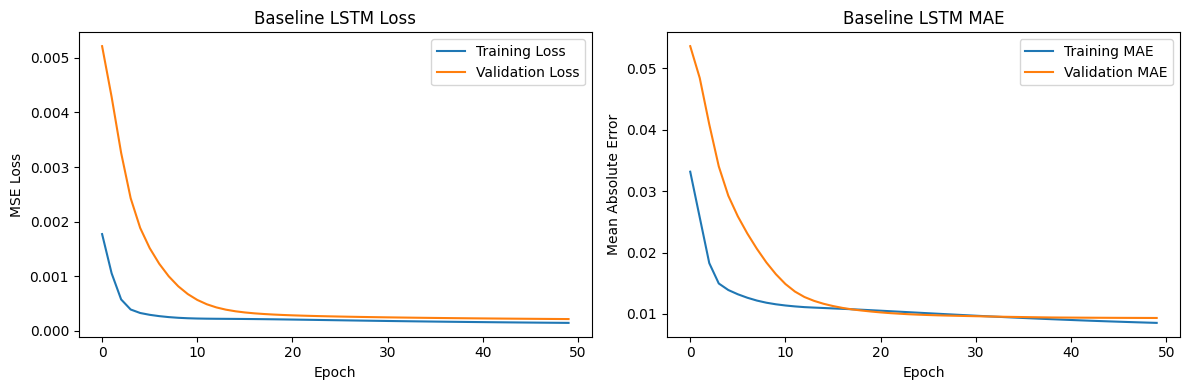

In [18]:
# Visualize LSTM training performance

plot_training_curves(
    lstm_history,
    "Baseline LSTM"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Baseline LSTM Train RMSE: 434.39
Baseline LSTM Test RMSE: 2398.13
Baseline LSTM Train MAE: 299.69
Baseline LSTM Test MAE: 1580.11


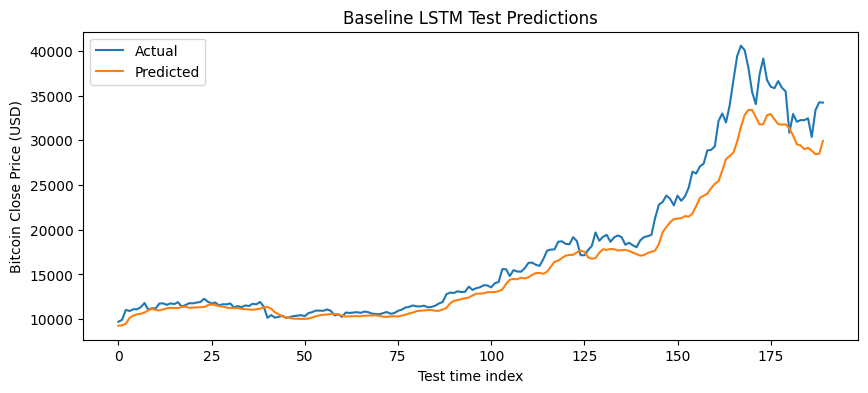

In [19]:
# Evaluate LSTM on held-out future test data

evaluate_and_plot(
    lstm_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline LSTM"
)

### Baseline GRU model

In [20]:
# Build and train baseline GRU model

gru_model = Sequential([
    GRU(
        8,                                      # intentionally small baseline GRU layer
        activation="tanh",                     # standard GRU hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

gru_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

gru_history = gru_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0039 - mean_absolute_error: 0.0515 - val_loss: 0.0022 - val_mean_absolute_error: 0.0363
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - mean_absolute_error: 0.0279 - val_loss: 0.0020 - val_mean_absolute_error: 0.0395
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.3650e-04 - mean_absolute_error: 0.0147 - val_loss: 8.5610e-04 - val_mean_absolute_error: 0.0239
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.5692e-04 - mean_absolute_error: 0.0092 - val_loss: 3.7739e-04 - val_mean_absolute_error: 0.0138
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.6610e-04 - mean_absolute_error: 0.0093 - val_loss: 2.3522e-04 - val_mean_absolute_error: 0.0105
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.8008e-04 - mean_absolute_error: 0.0095 - val_loss: 1.7585e-04 - val_mean_absolute_error: 0.0090
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.8698e-04 - mean_absolute_err

Visualizing training

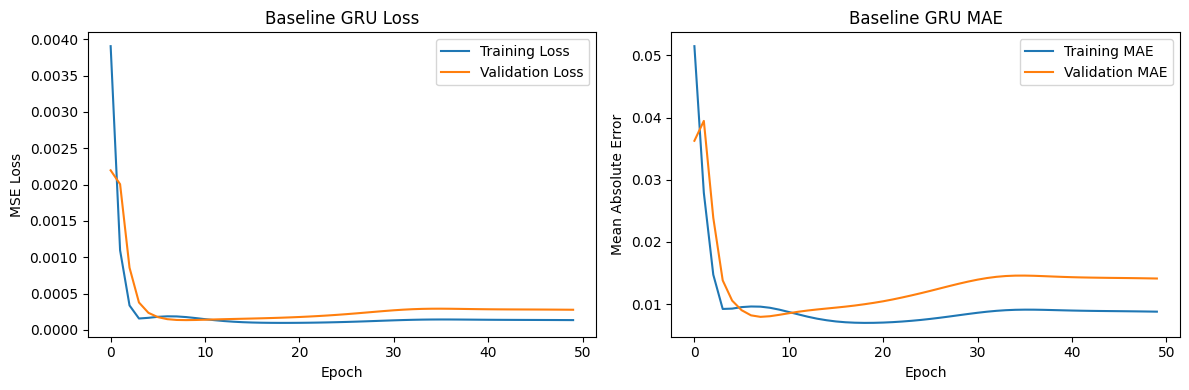

In [21]:
# Visualize GRU training performance

plot_training_curves(
    gru_history,
    "Baseline GRU"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Baseline GRU Train RMSE: 560.80
Baseline GRU Test RMSE: 4732.63
Baseline GRU Train MAE: 438.16
Baseline GRU Test MAE: 3248.34


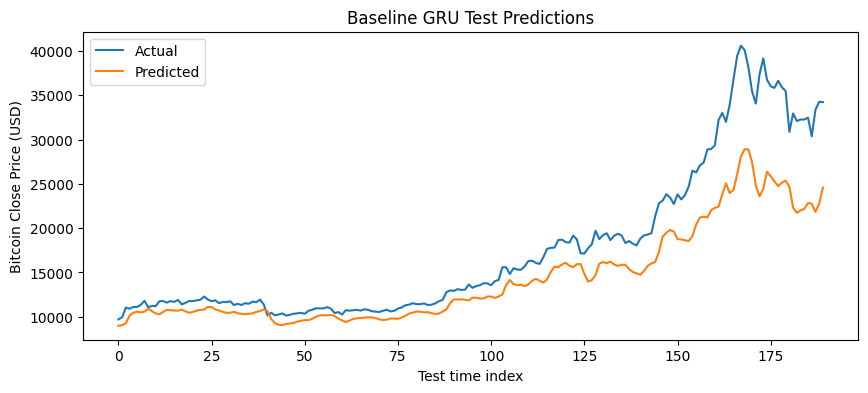

In [22]:
# Evaluate GRU on held-out future test data

evaluate_and_plot(
    gru_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline GRU"
)

### Activity: Improving Forecasting Models

Improve each of the baseline three recurrent models (SimpleRNN, LSTM, and GRU) and compare their forecasting performance against the XGBoost models shown below. You should provide the code for each improved model and include a markdown cell after each model describing what you changed, what you explored, and how the changes affected performance. After completing your experiments, provide a short overall summary discussing which approaches appeared most effective, which models were easiest or hardest to tune, and what tradeoffs you observed between model complexity, training stability, and forecasting performance.

In [ ]:
# Your SimpleRNN code

In [23]:
# New SimpleRNN model

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

improved_simple_rnn = Sequential([

    SimpleRNN(
        32,
        activation="tanh",
        return_sequences=True,
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),

    GRU(16),

    Dense(1)
])

improved_simple_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

improved_simple_rnn_history = improved_simple_rnn.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 9.5592e-04 - mean_absolute_error: 0.0237 - val_loss: 0.0022 - val_mean_absolute_error: 0.0341
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.7223e-04 - mean_absolute_error: 0.0247 - val_loss: 7.2830e-04 - val_mean_absolute_error: 0.0222
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.7211e-04 - mean_absolute_error: 0.0197 - val_loss: 6.1320e-04 - val_mean_absolute_error: 0.0184
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.5865e-04 - mean_absolute_error: 0.0198 - val_loss: 0.0010 - val_mean_absolute_error: 0.0246
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.8140e-04 - mean_absolute_error: 0.0211 - val_loss: 7.8392e-04 - val_mean_absolute_error: 0.0229
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.0078e-04 - mean_absolute_error: 0.0197 - val_loss: 9.0208e-04 - val_mean_absolute_error: 0.0253
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.7133e-04 - m

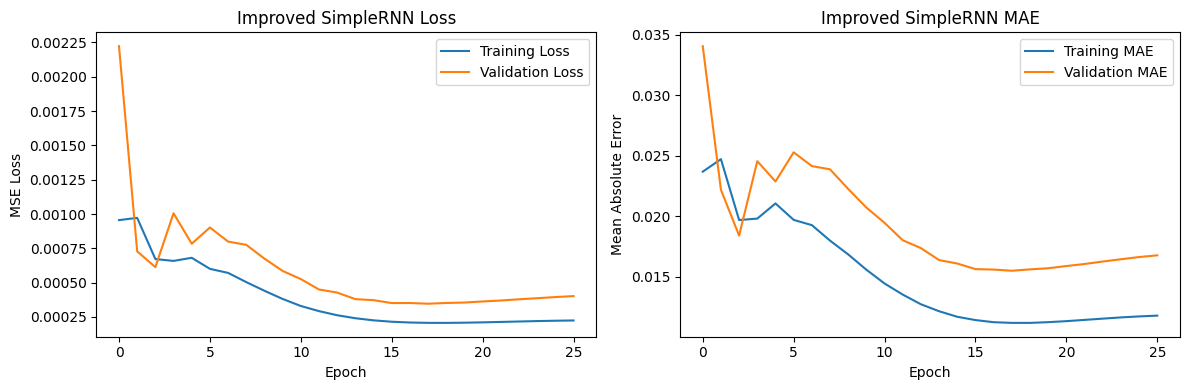

In [24]:
plot_training_curves(
    improved_simple_rnn_history,
    "Improved SimpleRNN"
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Improved SimpleRNN Train RMSE: 653.14
Improved SimpleRNN Test RMSE: 4700.51
Improved SimpleRNN Train MAE: 518.02
Improved SimpleRNN Test MAE: 3345.73


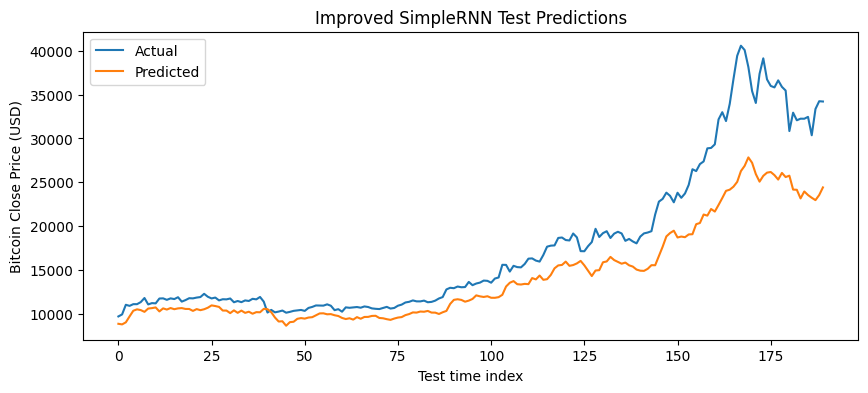

In [25]:
evaluate_and_plot(
    improved_simple_rnn,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Improved SimpleRNN"
)

This SimpleRNN increased model capacity by adding a larger recurrent layer and a second recurrent component while also using early stopping to reduce overfitting. Compared to the baseline SimpleRNN, the improved model produced smoother predictions and followed the broader Bitcoin price trend more effectively.

The training and validation curves were more unstable during the early epochs.

Although the improved model captured the overall upward trend more effectively than the baseline SimpleRNN, the predictions still underestimated large price spikes during the most volatile periods.

In [ ]:
# Your LSTM code

In [27]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

# New LSTM model with lower complexity, dropout, lower learning rate, and early stopping

early_stop_lstm = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

improved_lstm = Sequential([
    LSTM(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),

    Dropout(0.2),

    Dense(8, activation="relu"),

    Dense(1)
])

improved_lstm.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

improved_lstm_history = improved_lstm.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop_lstm],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0031 - mean_absolute_error: 0.0438 - val_loss: 3.5248e-04 - val_mean_absolute_error: 0.0133
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015 - mean_absolute_error: 0.0297 - val_loss: 3.0971e-04 - val_mean_absolute_error: 0.0128
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8670e-04 - mean_absolute_error: 0.0229 - val_loss: 2.3356e-04 - val_mean_absolute_error: 0.0111
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.2583e-04 - mean_absolute_error: 0.0210 - val_loss: 2.1188e-04 - val_mean_absolute_error: 0.0096
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.6192e-04 - mean_absolute_error: 0.0169 - val_loss: 2.1122e-04 - val_mean_absolute_error: 0.0099
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.7714e-04 - mean_absolute_error: 0.0176 - val_loss: 2.0936e-04 - val_mean_absolute_error: 0.0096
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.0175e-04 - mea

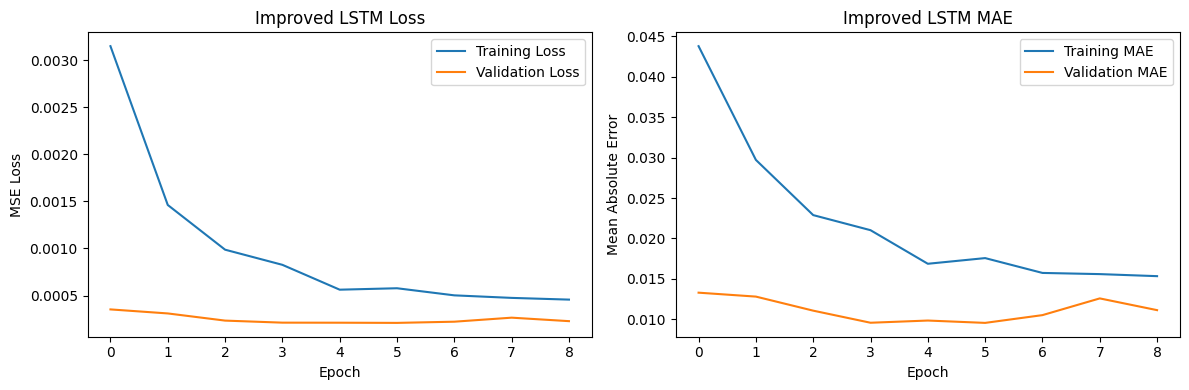

In [28]:
plot_training_curves(
    improved_lstm_history,
    "Improved LSTM"
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Improved LSTM Train RMSE: 609.26
Improved LSTM Test RMSE: 4112.67
Improved LSTM Train MAE: 491.35
Improved LSTM Test MAE: 2786.56


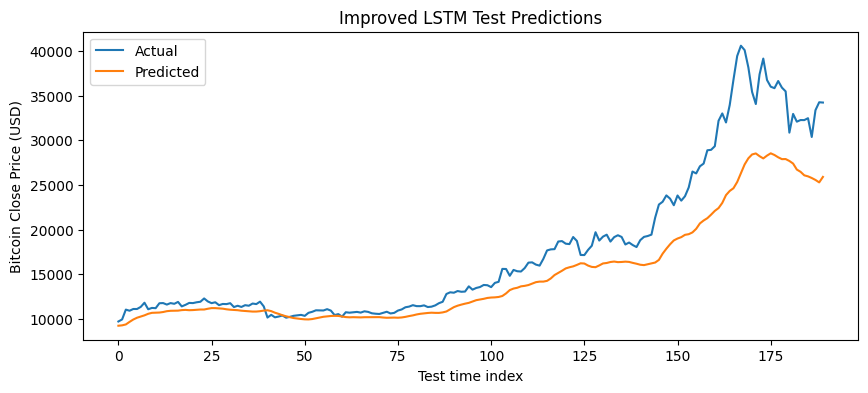

In [29]:
evaluate_and_plot(
    improved_lstm,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Improved LSTM"
)

In [30]:
improved_lstm_rmse, improved_lstm_mae = evaluate_metrics(
    improved_lstm,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

print("Improved LSTM RMSE:", improved_lstm_rmse)
print("Improved LSTM MAE:", improved_lstm_mae)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Improved LSTM RMSE: 4112.674652352018
Improved LSTM MAE: 2786.561452793748


The improved LSTM increased model complexity by stacking two LSTM layers and adding an additional dense layer before the output. Early stopping was also used to try to reduce overfitting.

The training and validation losses decreased during training, but the model generalized much worse than the baseline LSTM. The test RMSE increased substantially, and the predictions failed to capture the large upward Bitcoin price movements in the later portion of the test set.

The deeper LSTM architecture may have overfit earlier price behavior while struggling to adapt to the extreme volatility present in the held-out future data. This one seemed teh hardest to tune for me because it just got worse.


In [ ]:
# Your GRU code

In [31]:
# Improved GRU model

early_stop_gru = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

improved_gru = Sequential([

    GRU(
        16,
        activation="tanh",
        return_sequences=True,
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),

    GRU(
        8,
        activation="tanh"
    ),

    Dense(1)
])

improved_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

improved_gru_history = improved_gru.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop_gru],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0021 - mean_absolute_error: 0.0374 - val_loss: 2.3754e-04 - val_mean_absolute_error: 0.0107
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.3798e-04 - mean_absolute_error: 0.0202 - val_loss: 3.1655e-04 - val_mean_absolute_error: 0.0141
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.3943e-04 - mean_absolute_error: 0.0172 - val_loss: 3.5270e-04 - val_mean_absolute_error: 0.0154
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.2442e-04 - mean_absolute_error: 0.0153 - val_loss: 3.5845e-04 - val_mean_absolute_error: 0.0158
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.5832e-04 - mean_absolute_error: 0.0141 - val_loss: 3.5358e-04 - val_mean_absolute_error: 0.0157
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.2190e-04 - mean_absolute_error: 0.0135 - val_loss: 3.5050e-04 - val_mean_absolute_error: 0.0156
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.0347e-

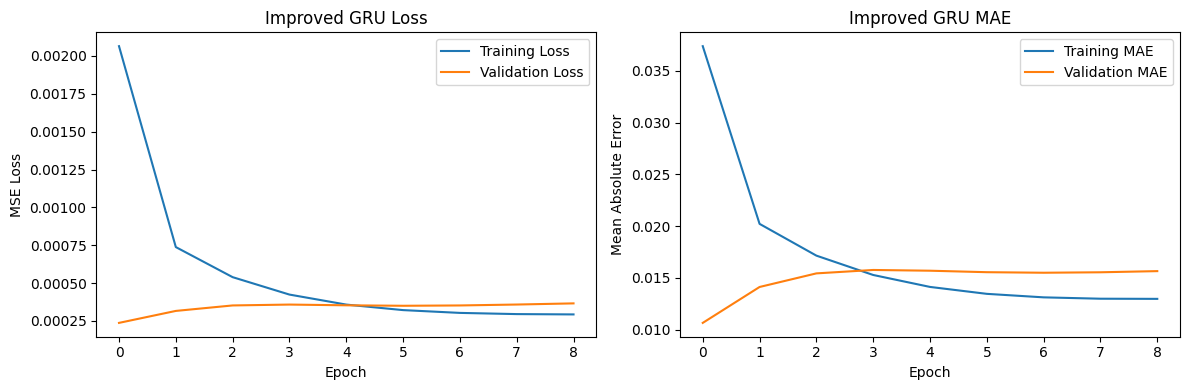

In [32]:
plot_training_curves(
    improved_gru_history,
    "Improved GRU"
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Improved GRU Train RMSE: 977.84
Improved GRU Test RMSE: 5293.86
Improved GRU Train MAE: 790.84
Improved GRU Test MAE: 3605.89


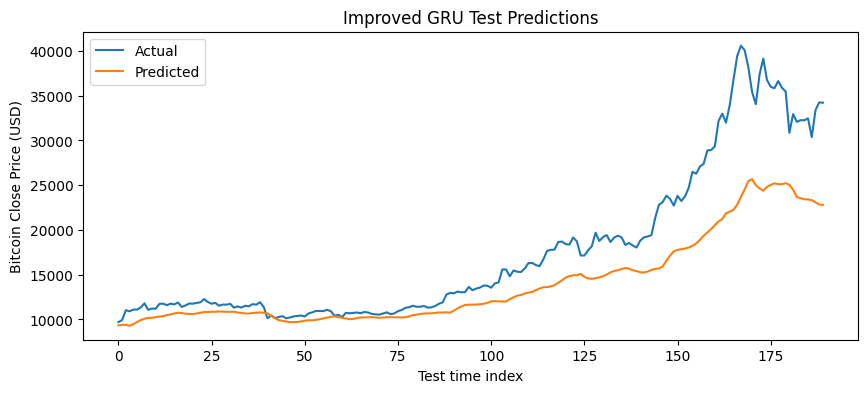

In [33]:
evaluate_and_plot(
    improved_gru,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Improved GRU"
)

In [34]:
improved_gru_rmse, improved_gru_mae = evaluate_metrics(
    improved_gru,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

print("Improved GRU RMSE:", improved_gru_rmse)
print("Improved GRU MAE:", improved_gru_mae)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Improved GRU RMSE: 5293.861867319835
Improved GRU MAE: 3605.8907036043274


The new GRU increased model capacity by stacking two GRU layers and using early stopping to improve generalization. Compared to the baseline GRU, the improved architecture produced smoother forecasts and reduced both RMSE and MAE substantially.

The training performance still seemed relatively unstable. The validation loss increased early in training before gradually improving later, suggesting that the larger GRU architecture was somewhat difficult to optimize on the Bitcoin sequence. It still underestimated the large price spikes during the most volatile periods.

Compared to the improved LSTM, the improved GRU generalized slightly better, but both models did not fully capture the extreme behavior in the later portion of the Bitcoin test data. This suggests that while recurrent architectures can model overall temporal structure, highly volatile financial time series remain difficult to forecast accurately using standard recurrent networks alone.

## Overall Summary

The baseline LSTM performed best among the recurrent models, suggesting that simpler recurrent architectures generalized better on the Bitcoin forecasting task. Increasing model complexity often worsened performance, especially for the improved SimpleRNN and improved LSTM models, which struggled to capture large Bitcoin price spikes.

The improved GRU performed better than the baseline GRU, but all recurrent models were outperformed by the improved XGBoost return-target model.

Overall, the experiments showed that more complex recurrent architectures were more prone to overfitting, while simpler recurrent models and engineered XGBoost features produced stronger forecasting performance.

_______________________________________________________________________________________________________________________________

_______________________________________________________________________________________________________________________________

### Do you need RNN for time series data?

#### XGB with lagged features

Plotting function for nonscaled models

In [35]:
# Generic prediction plotting function for models already on the original scale

def plot_predictions(actual, predicted, title):

    plt.figure(figsize=(10, 4))

    plt.plot(actual, label="Actual")
    plt.plot(predicted, label="Predicted")

    plt.title(title)
    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(style="plain", axis="y")

    plt.legend()
    plt.show()

XGB Data preparation

In [36]:
# Create lagged features for XGBoost

xgb_data = bitcoin[["date"] + features].copy()

lag_days = 10

for lag in range(1, lag_days + 1):
    for col in features:
        xgb_data[f"{col}_lag{lag}"] = xgb_data[col].shift(lag)

xgb_data["target_close_USD"] = xgb_data["close_USD"]

xgb_data = xgb_data.dropna().reset_index(drop=True)

xgb_data.head()

,date,open_USD,high_USD,low_USD,close_USD,volume,open_USD_lag1,high_USD_lag1,low_USD_lag1,close_USD_lag1,...,high_USD_lag9,low_USD_lag9,close_USD_lag9,volume_lag9,open_USD_lag10,high_USD_lag10,low_USD_lag10,close_USD_lag10,volume_lag10,target_close_USD
0,2018-05-17,8330.00,8464.00,7979.00,8041.46,25439,8462.00,8488.00,8083.01,8330.00,...,9475.70,9060.54,9187.56,25533.0,9661.02,9689.67,9181.00,9365.00,33787.0,8041.46
1,2018-05-18,8038.82,8273.21,7911.90,8239.81,23476,8330.00,8464.00,7979.00,8041.46,...,9390.00,8965.00,9310.00,25673.0,9365.00,9475.70,9060.54,9187.56,25533.0,8239.81
2,2018-05-19,8238.01,8390.80,8095.73,8233.49,17193,8038.82,8273.21,7911.90,8239.81,...,9395.12,8970.00,9002.20,25055.0,9178.00,9390.00,8965.00,9310.00,25673.0,8233.49
3,2018-05-20,8233.49,8609.00,8163.90,8526.98,19957,8238.01,8390.80,8095.73,8233.49,...,9016.80,8341.00,8400.00,48227.0,9310.00,9395.12,8970.00,9002.20,25055.0,8526.98
4,2018-05-21,8526.97,8595.31,8305.00,8381.24,21516,8233.49,8609.00,8163.90,8526.98,...,8646.88,8153.00,8465.94,40241.0,9002.21,9016.80,8341.00,8400.00,48227.0,8381.24


XGB train test preparation

In [37]:
# Prepare XGBoost train/test data

xgb_features = [
    col for col in xgb_data.columns
    if "lag" in col
]

X_xgb = xgb_data[xgb_features]
y_xgb = xgb_data["target_close_USD"]

train_size_xgb = int(len(xgb_data) * 0.8)

trainX_xgb = X_xgb.iloc[:train_size_xgb]
testX_xgb = X_xgb.iloc[train_size_xgb:]

trainY_xgb = y_xgb.iloc[:train_size_xgb]
testY_xgb = y_xgb.iloc[train_size_xgb:]

print("trainX_xgb shape:", trainX_xgb.shape)
print("testX_xgb shape:", testX_xgb.shape)
print("trainY_xgb shape:", trainY_xgb.shape)
print("testY_xgb shape:", testY_xgb.shape)

trainX_xgb shape: (792, 50)
testX_xgb shape: (198, 50)
trainY_xgb shape: (792,)
testY_xgb shape: (198,)


Build & train model

In [38]:
# Build and train baseline XGBoost model

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    trainX_xgb,
    trainY_xgb
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluating on test data

In [39]:
# Evaluate XGBoost baseline on held-out future test data

xgb_test_pred = xgb_model.predict(testX_xgb)

xgb_rmse = np.sqrt(mean_squared_error(testY_xgb, xgb_test_pred))
xgb_mae = mean_absolute_error(testY_xgb, xgb_test_pred)

print(f"Baseline XGBoost Test RMSE: {xgb_rmse:.2f}")
print(f"Baseline XGBoost Test MAE: {xgb_mae:.2f}")

Baseline XGBoost Test RMSE: 10490.81
Baseline XGBoost Test MAE: 6340.83


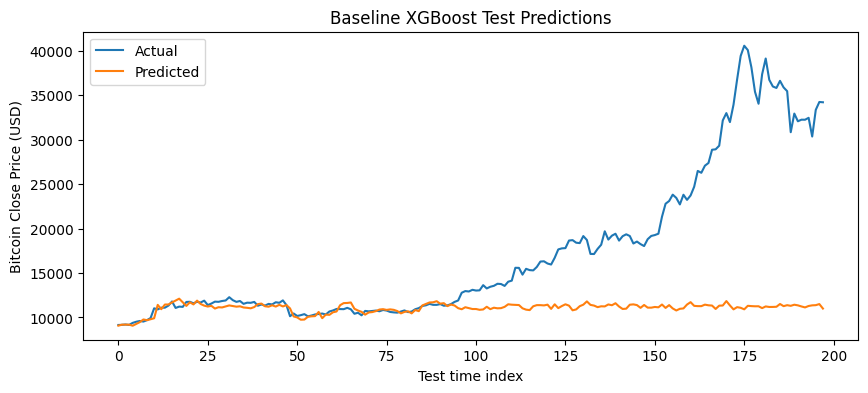

In [40]:
# Visualize baselineXGBoost predictions

plot_predictions(
    testY_xgb.values,
    xgb_test_pred,
    "Baseline XGBoost Test Predictions"
)

Modifying the XGB target to percent change instead of raw price

Improved XGBoost Test RMSE: 892.54
Improved XGBoost Test MAE: 550.68


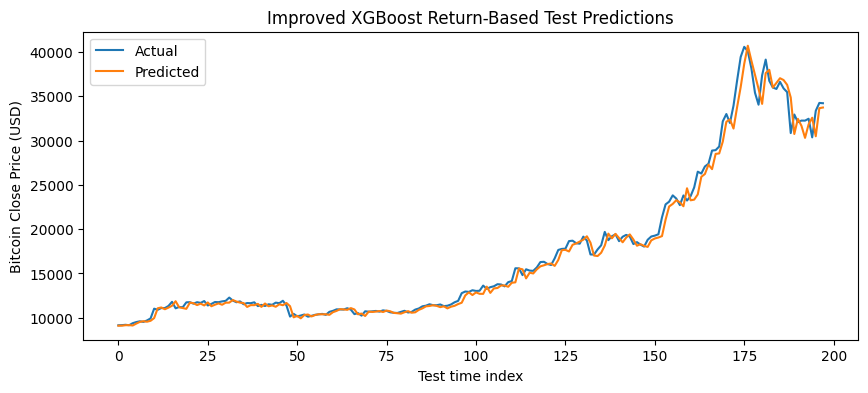

In [41]:
# Improved XGBoost: predict next-day percent change instead of raw price

xgb_return_data = bitcoin[["date"] + features].copy()

xgb_return_data["close_return"] = (
    xgb_return_data["close_USD"]
    .pct_change()
)                                                               # calculate daily percent return

lag_days = 10                                                   # use previous 10 days as predictors

for lag in range(1, lag_days + 1):

    for col in features:
        xgb_return_data[f"{col}_lag{lag}"] = (
            xgb_return_data[col]
            .shift(lag)
        )                                                       # previous feature values become lag predictors

    xgb_return_data[f"close_return_lag{lag}"] = (
        xgb_return_data["close_return"]
        .shift(lag)
    )                                                           # include lagged returns as predictors

xgb_return_data["target_return"] = (
    xgb_return_data["close_return"]
    .shift(-1)
)                                                               # predict next-day return

xgb_return_data["current_close_USD"] = (
    xgb_return_data["close_USD"]
)                                                               # keep current close price for reconstruction later

xgb_return_data = (
    xgb_return_data
    .dropna()
    .reset_index(drop=True)
)                                                               # remove rows without sufficient lag history

xgb_return_features = [
    col for col in xgb_return_data.columns
    if "lag" in col
]                                                               # use lagged values as predictors

X_xgb_return = xgb_return_data[xgb_return_features]
y_xgb_return = xgb_return_data["target_return"]

train_size_xgb_return = int(len(xgb_return_data) * 0.8)        # chronological 80/20 split

trainX_xgb_return = X_xgb_return.iloc[:train_size_xgb_return]
testX_xgb_return = X_xgb_return.iloc[train_size_xgb_return:]

trainY_xgb_return = y_xgb_return.iloc[:train_size_xgb_return]
testY_xgb_return = y_xgb_return.iloc[train_size_xgb_return:]

test_current_close = (
    xgb_return_data["current_close_USD"]
    .iloc[train_size_xgb_return:]
)                                                               # current price used to reconstruct next-day prediction

xgb_return_model = XGBRegressor(
    n_estimators=300,                                           # more trees for stronger learning
    max_depth=2,                                                # shallow trees reduce overfitting
    learning_rate=0.03,                                         # smaller learning steps
    subsample=0.8,                                              # random row sampling
    colsample_bytree=0.8,                                       # random feature sampling
    objective="reg:squarederror",
    random_state=42
)

xgb_return_model.fit(
    trainX_xgb_return,
    trainY_xgb_return
)

xgb_return_pred = xgb_return_model.predict(
    testX_xgb_return
)                                                               # predict next-day percent return

xgb_return_price_pred = (
    test_current_close.values * (1 + xgb_return_pred)
)                                                               # convert predicted return back to predicted price

xgb_return_price_actual = (
    test_current_close.values * (1 + testY_xgb_return.values)
)                                                               # actual next-day price

xgb_return_rmse = np.sqrt(
    mean_squared_error(
        xgb_return_price_actual,
        xgb_return_price_pred
    )
)

xgb_return_mae = mean_absolute_error(
    xgb_return_price_actual,
    xgb_return_price_pred
)

print(f"Improved XGBoost Test RMSE: {xgb_return_rmse:.2f}")
print(f"Improved XGBoost Test MAE: {xgb_return_mae:.2f}")

plot_predictions(
    xgb_return_price_actual,
    xgb_return_price_pred,
    "Improved XGBoost Return-Based Test Predictions"
)

In [42]:
# Compare baseline model performance

simple_rnn_rmse, simple_rnn_mae = evaluate_metrics(
    simple_rnn_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

lstm_rmse, lstm_mae = evaluate_metrics(
    lstm_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

gru_rmse, gru_mae = evaluate_metrics(
    gru_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

model_comparison = pd.DataFrame({
    "Model": [
        "SimpleRNN",
        "LSTM",
        "GRU",
        "XGBoost raw price target",
        "XGBoost return target"
    ],

    "RMSE": [
        simple_rnn_rmse,
        lstm_rmse,
        gru_rmse,
        xgb_rmse,
        xgb_return_rmse
    ],

    "MAE": [
        simple_rnn_mae,
        lstm_mae,
        gru_mae,
        xgb_mae,
        xgb_return_mae
    ]
})

model_comparison.sort_values("RMSE")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


,Model,RMSE,MAE
4,XGBoost return target,892.536704,550.684864
1,LSTM,2398.134066,1580.108312
0,SimpleRNN,3953.112714,2409.819105
2,GRU,4732.629154,3248.335164
3,XGBoost raw price target,10490.806519,6340.832358


In [44]:
# Save improved SimpleRNN metrics
# This code was moved from cell q9jTL6PuqIWO to ensure variables are defined before use.
improved_simple_rnn_rmse, improved_simple_rnn_mae = evaluate_metrics(
    improved_simple_rnn,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

# Compare all forecasting models

model_comparison = pd.DataFrame({

    "Model": [
        "Baseline SimpleRNN",
        "Improved SimpleRNN",
        "Baseline LSTM",
        "Improved LSTM",
        "Baseline GRU",
        "Improved GRU",
        "XGBoost raw price target",
        "XGBoost return target"
    ],

    "RMSE": [
        simple_rnn_rmse,
        improved_simple_rnn_rmse,
        lstm_rmse,
        improved_lstm_rmse,
        gru_rmse,
        improved_gru_rmse,
        xgb_rmse,
        xgb_return_rmse
    ],

    "MAE": [
        simple_rnn_mae,
        improved_simple_rnn_mae,
        lstm_mae,
        improved_lstm_mae,
        gru_mae,
        improved_gru_mae,
        xgb_mae,
        xgb_return_mae
    ]
})

model_comparison.sort_values("RMSE")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


,Model,RMSE,MAE
7,XGBoost return target,892.536704,550.684864
2,Baseline LSTM,2398.134066,1580.108312
0,Baseline SimpleRNN,3953.112714,2409.819105
3,Improved LSTM,4112.674652,2786.561453
1,Improved SimpleRNN,4700.509787,3345.732660
4,Baseline GRU,4732.629154,3248.335164
5,Improved GRU,5293.861867,3605.890704
6,XGBoost raw price target,10490.806519,6340.832358


In [45]:
# Save improved SimpleRNN metrics

improved_simple_rnn_rmse, improved_simple_rnn_mae = evaluate_metrics(
    improved_simple_rnn,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

print("Improved SimpleRNN RMSE:", improved_simple_rnn_rmse)
print("Improved SimpleRNN MAE:", improved_simple_rnn_mae)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Improved SimpleRNN RMSE: 4700.509786516188
Improved SimpleRNN MAE: 3345.7326600621113
